<a href="https://colab.research.google.com/github/johnerrolcxrdenad-svg/FUNDAI-Laboratories-Cardenas/blob/main/Lab2_Search_Algorithms_Cardenas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Maze Solving Using BFS, DFS, and A* Search

## Fundamentals of Artificial Intelligence

**Name:** John Errol S. Cardenas
**Course:** FUNDAI
**Section:** 09282
**Date:** August 20, 2026  

**GitHub URL:** https://github.com/johnerrolcxrdenad-svg

## Description
This laboratory implements BFS, DFS, and A* Search to solve a maze.
The search results are visualized using matplotlib.


In [15]:
from collections import deque
import heapq
import numpy as np
import matplotlib.pyplot as plt

## Maze Class

The `Maze` class stores the grid, start position, and goal position.
The value `0` represents an open cell.
The value `1` represents a wall.

In [16]:
class Maze:
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0]) if self.rows > 0 else 0

    def inside(self, pos):
        r, c = pos
        return 0 <= r < self.rows and 0 <= c < self.cols

    def passable(self, pos):
        if not self.inside(pos):
            return False
        r, c = pos
        return self.grid[r][c] == 0

    def neighbors(self, pos):
        r, c = pos
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        result = []

        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            next_pos = (nr, nc)

            if self.passable(next_pos):
                result.append(next_pos)

        return result

## SearchResult Class

The `SearchResult` class stores the output of each search algorithm.
It includes the algorithm name, success status, path, visited order, and parent map.

In [17]:
class SearchResult:
    def __init__(self, algorithm, success, path, visited_order, parent, root):
        self.algorithm = algorithm
        self.success = success
        self.path = path
        self.visited_order = visited_order
        self.parent = parent
        self.root = root

        self.path_set = set(path)
        self.visited_set = set(visited_order)

    @property
    def path_length(self):
        return len(self.path)

    @property
    def nodes_expanded(self):
        return len(self.visited_order)

    def summary(self):
        print(f"Algorithm: {self.algorithm}")
        print(f"Success: {self.success}")
        print(f"Path length: {self.path_length}")
        print(f"Nodes expanded/popped: {self.nodes_expanded}")
        print(f"Path: {self.path}")
        print("-" * 50)

## SearchSolver Class

The `SearchSolver` class contains the implementation of BFS, DFS, and A* Search.

In [18]:
class SearchSolver:
    def __init__(self, maze):
        self.maze = maze

    def _reconstruct_path(self, parent, goal):
        path = []
        current = goal

        while current is not None:
            path.append(current)
            current = parent[current]

        path.reverse()
        return path

    def _heuristic(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def bfs(self):
      start = self.maze.start
      goal = self.maze.goal

      if not self.maze.passable(start) or not self.maze.passable(goal):
        return SearchResult("BFS", False, [], [], {start: None}, start)

      frontier = deque([start])
      visited = {start}
      parent = {start: None}
      visited_order = []
      success = False

      while frontier:
          current = frontier.popleft()
          visited_order.append(current)

          if current == goal:
              success = True
              break

          for neighbor in self.maze.neighbors(current):
              if neighbor not in visited:
                  visited.add(neighbor)
                  parent[neighbor] = current
                  frontier.append(neighbor)

      path = self._reconstruct_path(parent, goal) if success else []

      return SearchResult(
        algorithm="BFS",
        success=success,
        path=path,
        visited_order=visited_order,
        parent=parent,
        root=start
    )

    def astar(self):
      start = self.maze.start
      goal = self.maze.goal

      if not self.maze.passable(start) or not self.maze.passable(goal):
          return SearchResult("A* Search", False, [], [], {start: None}, start)

      counter = 0
      open_heap = []
      heapq.heappush(open_heap, (0, counter, start))

      g_score = {start: 0}
      parent = {start: None}
      visited = set()
      visited_order = []
      success = False

      while open_heap:
          f, _, current = heapq.heappop(open_heap)

          if current in visited:
              continue

          visited.add(current)
          visited_order.append(current)

          if current == goal:
              success = True
              break

          for neighbor in self.maze.neighbors(current):
              tentative_g = g_score[current] + 1

              if tentative_g < g_score.get(neighbor, float('inf')):
                  g_score[neighbor] = tentative_g
                  f_score = tentative_g + self._heuristic(neighbor, goal)

                  parent[neighbor] = current
                  counter += 1
                  heapq.heappush(open_heap, (f_score, counter, neighbor))

      path = self._reconstruct_path(parent, goal) if success else []

      return SearchResult(
          algorithm="A* Search",
          success=success,
          path=path,
          visited_order=visited_order,
          parent=parent,
          root=start
    )

## Sample Maze

The maze user

- `0` for open cells
- `1` for walls

In [19]:
grid = [
    [0, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (6, 6)

maze = Maze(grid, start, goal)
solver = SearchSolver(maze)

In [20]:
bfs_result = solver.bfs()
dfs_result = solver.bfs()
astar_result = solver.astar()

In [21]:
bfs_result.summary()
dfs_result.summary()
astar_result.summary()

Algorithm: BFS
Success: True
Path length: 13
Nodes expanded/popped: 30
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
--------------------------------------------------
Algorithm: BFS
Success: True
Path length: 13
Nodes expanded/popped: 30
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
--------------------------------------------------
Algorithm: A* Search
Success: True
Path length: 13
Nodes expanded/popped: 14
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
--------------------------------------------------


In [22]:
def visualize_search(maze, result, title="Search Result"):
    img = np.ones((maze.rows, maze.cols, 3))

    # Draw walls
    for r in range(maze.rows):
        for c in range(maze.cols):
            if maze.grid[r][c] == 1:
                img[r, c] = (0.1, 0.1, 0.1)

    if result is not None:
        # Draw visited/expanded cells
        for r, c in result.visited_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (0.75, 0.87, 1.0)

        # Draw final path
        for r, c in result.path_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (1.0, 0.85, 0.3)

    # Draw start and goal
    img[maze.start] = (0.2, 0.8, 0.2)
    img[maze.goal] = (0.9, 0.2, 0.2)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

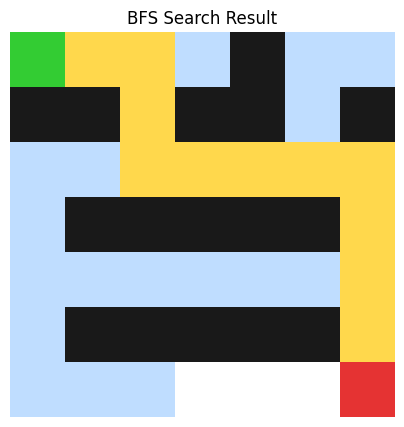

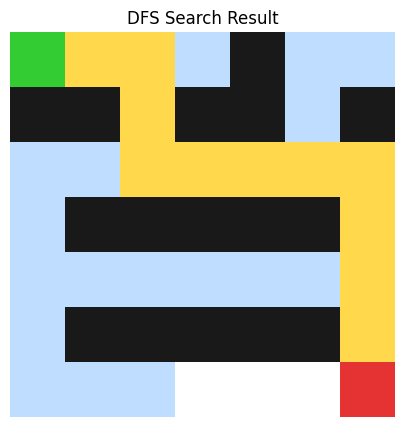

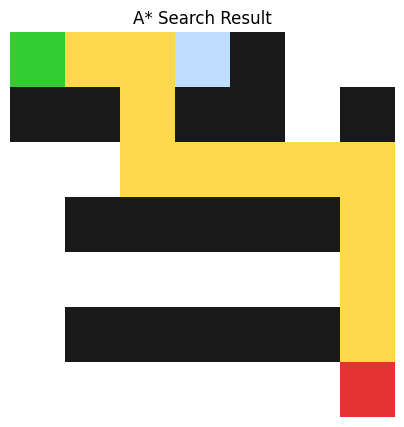

In [23]:
visualize_search(maze, bfs_result, "BFS Search Result")
visualize_search(maze, dfs_result, "DFS Search Result")
visualize_search(maze, astar_result, "A* Search Result")

In [24]:
def search_tree_text(result, max_lines=100):
    children = {}

    for child, predecessor in result.parent.items():
        if predecessor is not None:
            if predecessor not in children:
                children[predecessor] = []
            children[predecessor].append(child)

    for node in children:
        children[node].sort()

    lines = []

    def build(node, depth):
        if len(lines) >= max_lines:
            return

        lines.append("  " * depth + str(node))

        for child in children.get(node, []):
            build(child, depth + 1)

    build(result.root, 0)

    if len(lines) >= max_lines:
        lines.append("... search tree truncated for report")

    return "\n".join(lines)

In [25]:
print("BFS Search Tree")
print(search_tree_text(bfs_result, max_lines=80))

print("\nDFS Search Tree")
print(search_tree_text(dfs_result, max_lines=80))

print("\nA* Search Tree")
print(search_tree_text(astar_result, max_lines=80))

BFS Search Tree
(0, 0)
  (0, 1)
    (0, 2)
      (0, 3)
      (1, 2)
        (2, 2)
          (2, 1)
            (2, 0)
              (3, 0)
                (4, 0)
                  (4, 1)
                    (4, 2)
                      (4, 3)
                        (4, 4)
                  (5, 0)
                    (6, 0)
                      (6, 1)
                        (6, 2)
                          (6, 3)
          (2, 3)
            (2, 4)
              (2, 5)
                (1, 5)
                  (0, 5)
                    (0, 6)
                (2, 6)
                  (3, 6)
                    (4, 6)
                      (4, 5)
                      (5, 6)
                        (6, 6)

DFS Search Tree
(0, 0)
  (0, 1)
    (0, 2)
      (0, 3)
      (1, 2)
        (2, 2)
          (2, 1)
            (2, 0)
              (3, 0)
                (4, 0)
                  (4, 1)
                    (4, 2)
                      (4, 3)
                        (4, 4)
      

In [26]:
def expansion_report(result, first_n=20):
    print(f"{result.algorithm} expansion order, first {first_n} nodes:")
    print(result.visited_order[:first_n])
    print("-" * 50)

expansion_report(bfs_result)
expansion_report(dfs_result)
expansion_report(astar_result)

BFS expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (0, 3), (2, 2), (2, 1), (2, 3), (2, 0), (2, 4), (3, 0), (2, 5), (4, 0), (1, 5), (2, 6), (5, 0), (4, 1), (0, 5), (3, 6), (6, 0)]
--------------------------------------------------
BFS expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (0, 3), (2, 2), (2, 1), (2, 3), (2, 0), (2, 4), (3, 0), (2, 5), (4, 0), (1, 5), (2, 6), (5, 0), (4, 1), (0, 5), (3, 6), (6, 0)]
--------------------------------------------------
A* Search expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (0, 3), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]
--------------------------------------------------


### BFS
BFS explores the maze level by level. It is useful for finding a shortest path when all move costs are equal.

### DFS
DFS explores one branch deeply before backtracking. It may find a solution quickly, but the path may not be short.

### A* Search
A* uses both actual cost from the start and estimated cost to the goal. With Manhattan distance, it is often more efficient than BFS.

### Observation
[Write your observation here. Compare path length, number of expanded nodes, and behavior.]

## Guide Questions and Answers

### 1. Which algorithm found the shortest path?
**Answer:** Both BFS and A Search* found the shortest path. BFS guarantees the shortest path in unweighted grids by exploring level-by-level, while A* Search with an admissible heuristic (like Manhattan distance) is also guaranteed to find the optimal shortest path.

### 2. Which algorithm expanded the fewest nodes?
**Answer:** A Search* expanded the fewest nodes. By using the Manhattan distance heuristic, A* prioritizes exploring nodes that are closer to the goal, avoiding unnecessary node expansions compared to BFS and DFS.

### 3. Why is Manhattan distance suitable for this maze?
**Answer:** because movement in the grid maze is restricted to 4 directions (up, down, left, right) without diagonal moves. Furthermore, it is an admissible heuristic (it never overestimates the true cost to reach the goal), ensuring A* remains optimal.

### 4. How does the parent map help reconstruct the path?
**Answer:** The parent map stores each node's predecessor key-value pair (child: parent). Starting from the goal node, you can trace backward step-by-step through its parent pointers until reaching the start/root node, and then reversing that path yields the route from start to goal.

### 5. Why is repeated-state checking important?
**Answer:** Repeated-state checking (maintaining a set of visited/expanded nodes) prevents the algorithm from processing the same cell multiple times. This avoids infinite loops in graphs with cycles and drastically reduces redundant computation and memory usage.

## Reflection

### Challenges Encountered
- During this lab, I faced challenges in managing algorithm state mappings to prevent infinite loops, correctly mapping grid matrix coordinates to Matplotlib visual overlays, and ensuring the Manhattan distance heuristic was implemented efficiently without sacrificing path optimality.

### What I Learned
- I learned the key trade-offs between search strategies—specifically how BFS guarantees optimal paths with high node expansion, DFS explores deeply but yields suboptimal routes, and A* optimizes efficiency using goal-guided heuristics—while gaining hands-on experience using parent-node mappings for path reconstruction and recursive formatting for search tree visualisations.